# Evolución de los Costos Marginales, Datos de Francisco

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unidecode as ud

In [5]:
df_cmg = pd.read_excel('cmg_comuna_bloque.xlsx', sheet_name='CMG_Comuna')
df_cmg

,periodo,nombre_comuna,bloque_horario,cmg_usd_mwh
0,2022-01-01,Algarrobo,A,140.270708
1,2022-01-01,Algarrobo,B,76.155321
2,2022-01-01,Algarrobo,C,155.459730
3,2022-01-01,Alhué,A,115.047350
4,2022-01-01,Alhué,B,50.642923
...,...,...,...,...
27772,2025-10-01,Yungay,B,6.324862
27773,2025-10-01,Yungay,C,47.977402
27774,2025-10-01,Zapallar,A,56.146161
27775,2025-10-01,Zapallar,B,6.805919


In [6]:
# Asegurar que 'periodo' sea datetime (por si acaso)
df_cmg['periodo'] = pd.to_datetime(df_cmg['periodo'])

# Crear columnas año y mes
df_cmg['anio'] = df_cmg['periodo'].dt.year
df_cmg['mes'] = df_cmg['periodo'].dt.month

# Eliminar la columna original
df_cmg = df_cmg.drop(columns='periodo')
df_cmg

,nombre_comuna,bloque_horario,cmg_usd_mwh,anio,mes
0,Algarrobo,A,140.270708,2022,1
1,Algarrobo,B,76.155321,2022,1
2,Algarrobo,C,155.459730,2022,1
3,Alhué,A,115.047350,2022,1
4,Alhué,B,50.642923,2022,1
...,...,...,...,...,...
27772,Yungay,B,6.324862,2025,10
27773,Yungay,C,47.977402,2025,10
27774,Zapallar,A,56.146161,2025,10
27775,Zapallar,B,6.805919,2025,10


In [7]:
# ponderadores residenciales (proporción diaria)
wA, wC = 0.18, 0.33
w_sum = wA + wC

# CMg ponderado A+C ---
df_ac = df_cmg[df_cmg['bloque_horario'].isin(['A', 'C'])].copy()
df_ac['ponderador'] = df_ac['bloque_horario'].map({'A': wA, 'C': wC})

cmg_ac = (
    df_ac
    .assign(cmg_w=lambda x: x['cmg_usd_mwh'] * x['ponderador'])
    .groupby(['anio', 'mes', 'nombre_comuna'], as_index=False)
    .agg(cmg_ac_usd_mwh=('cmg_w', 'sum'))
)

# normalizar por la suma de ponderadores (0.51)
cmg_ac['cmg_ac_usd_mwh'] = cmg_ac['cmg_ac_usd_mwh'] / w_sum


# CMg del bloque B ---
cmg_b = (
    df_cmg[df_cmg['bloque_horario'] == 'B']
    .loc[:, ['anio', 'mes', 'nombre_comuna', 'cmg_usd_mwh']]
    .rename(columns={'cmg_usd_mwh': 'cmg_b_usd_mwh'})
)


# Unir en una sola tabla ---
cmg_final = (
    cmg_b
    .merge(cmg_ac, on=['anio', 'mes', 'nombre_comuna'], how='outer')
    .sort_values(['anio', 'mes', 'nombre_comuna'])
    .reset_index(drop=True)
)

cmg_final["Diferencial [USD/MWh]"] = cmg_final["cmg_ac_usd_mwh"] - cmg_final["cmg_b_usd_mwh"]

df_2025 = cmg_final[cmg_final['anio'] == 2025].copy()

cmg_2025 = (
    df_2025
    .groupby('nombre_comuna', as_index=False)
    .agg(
        CMg_diferencial_2025_usd_mwh=('Diferencial [USD/MWh]', 'mean')
    )
)

# Se normalizan las columnas Comuna y Distribuidor
for col in ["nombre_comuna"]:
    cmg_2025[col] = (cmg_2025[col].str.lower()                                             	# Se vuelve minúscula
									.apply(lambda x: ud.unidecode(x) if pd.notna(x) else x)  # Se eliminan acentos
									.str.strip())                                            # Se eliminan espacios en blanco

cmg_2025 = cmg_2025.rename(columns={'nombre_comuna': 'Comuna'})
cmg_2025

,Comuna,CMg_diferencial_2025_usd_mwh
0,algarrobo,48.351236
1,alhue,52.348734
2,alto biobio,30.504283
3,alto hospicio,77.464038
4,alto del carmen,65.421322
...,...,...
198,vina del mar,42.182717
199,yerbas buenas,37.775360
200,yungay,33.192101
201,zapallar,47.517944


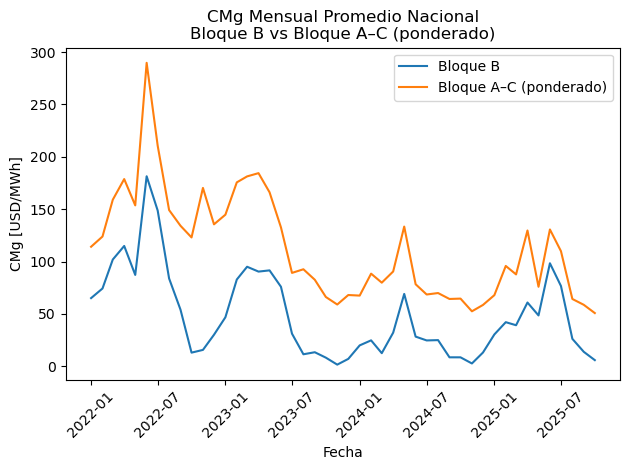

In [8]:
cmg_nacional_2 = (
    cmg_final
    .groupby(['anio', 'mes'], as_index=False)
    .agg(
        cmg_b_nacional=('cmg_b_usd_mwh', 'mean'),
        cmg_ac_nacional=('cmg_ac_usd_mwh', 'mean')
    )
)

# crear fecha
cmg_nacional_2['fecha'] = pd.to_datetime(
    cmg_nacional_2['anio'].astype(str) + '-' +
    cmg_nacional_2['mes'].astype(str) + '-01'
)

cmg_nacional_2 = cmg_nacional_2.sort_values('fecha')

plt.figure()

plt.plot(
    cmg_nacional_2['fecha'],
    cmg_nacional_2['cmg_b_nacional'],
    label='Bloque B'
)

plt.plot(
    cmg_nacional_2['fecha'],
    cmg_nacional_2['cmg_ac_nacional'],
    label='Bloque A–C (ponderado)'
)

plt.xlabel('Fecha')
plt.ylabel('CMg [USD/MWh]')
plt.title('CMg Mensual Promedio Nacional\nBloque B vs Bloque A–C (ponderado)')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

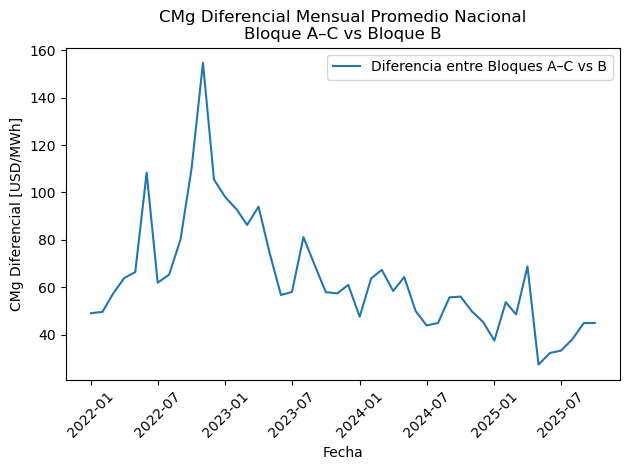

In [9]:
cmg_nacional_3 = (
    cmg_final
    .groupby(['anio', 'mes'], as_index=False)
    .agg(
        cmg_diferencial=('Diferencial [USD/MWh]', 'mean')
    )
)

# crear fecha
cmg_nacional_3['fecha'] = pd.to_datetime(
    cmg_nacional_3['anio'].astype(str) + '-' +
    cmg_nacional_3['mes'].astype(str) + '-01'
)

cmg_nacional_3 = cmg_nacional_3.sort_values('fecha')

plt.figure()

plt.plot(
    cmg_nacional_3['fecha'],
    cmg_nacional_3['cmg_diferencial'],
    label='Diferencia entre Bloques A–C vs B'
)

plt.xlabel('Fecha')
plt.ylabel('CMg Diferencial [USD/MWh]')
plt.title('CMg Diferencial Mensual Promedio Nacional\nBloque A–C vs Bloque B')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Se guardan los cambios para su uso en *CB_implementacion_SMI_Chile_resultados - ...*

In [11]:
# se guarda el archivo en formato excel
cmg_2025.to_excel('./cmg_diferencial2025_bloque_AC_vs_B.xlsx', index=False)